In [1]:
import numpy as np
import json
from transformers import BertTokenizer, BertModel, BertForMaskedLM
from tqdm import tqdm
import torch
import torch.nn.functional as F

/opt/anaconda3/envs/m1-gender/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model_version = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_version)
model = BertModel.from_pretrained(model_version, output_attentions=True)

In [6]:
#作ったデータセットの読み込み
with open("occupation_male.json") as f:
    data_male = json.load(f)
    
with open("occupation_female.json") as f:
    data_female = json.load(f)

In [7]:
data_male.keys()

dict_keys(['carpenter', 'mechanician', 'construction worker', 'laborer', 'driver', 'sheriff', 'mover', 'developer', 'farmer', 'guard', 'chief', 'janitor', 'lawyer', 'cook', 'physician', 'ceo', 'analyst', 'manager', 'supervisor', 'salesperson', 'editor', 'designer', 'accountant', 'auditor', 'writer', 'baker', 'clerk', 'cashier', 'counselor', 'attendant', 'teacher', 'sewer', 'librarian', 'assistant', 'cleaner', 'housekeeper', 'nurse', 'receptionist', 'hairdresser', 'secretary'])

#### レイヤー間の比較
各職業の文で，職業から主語へのAttentionの平均をレイヤーごとに比較するため

In [12]:
#職業単語
occupation_word = "cleaner"
occupation_inputs = tokenizer(occupation_word, return_tensors='pt', add_special_tokens=False)
occupation_ids = occupation_inputs['input_ids']
occupations = tokenizer.convert_ids_to_tokens(occupation_ids[0])

#各データセット
sub_data_m = data_male[occupation_word]
sub_data_f = data_female[occupation_word]

#結果格納
layers_m = []
layers_f = []

for l in range(12):
    #対象のレイヤー
    layer = l
    male_ats = []
    female_ats = []

    for i in tqdm(range(len(sub_data_m))):
        #初期化
        pos_m_oc = 0
        pos_f_oc = 0
    
        #男性文
        text_m = sub_data_m[i]
        inputs_m = tokenizer(text_m, return_tensors='pt')
        ids_m = inputs_m['input_ids']
        tokens_m = tokenizer.convert_ids_to_tokens(ids_m[0])
    
        with torch.no_grad():
            outputs_m = model(**inputs_m, output_attentions=True)
            attentions_m = outputs_m.attentions
    
        for j in range(len(tokens_m)): #職業単語の位置を取得
            if tokens_m[j] == occupation_word:
                pos_m_oc = j
    
        if pos_m_oc == 0:
            print("Occupation word not included!")
        
        attentions_m = attentions_m[layer][0].detach().numpy() #最終層とバッチの取り出し
        attentions_m = attentions_m.sum(axis=0) #headの合計
        male_weight = attentions_m[pos_m_oc, 1]
    
        male_ats.append(male_weight)
    
        #女性文
        text_f = sub_data_f[i]
        inputs_f = tokenizer(text_f, return_tensors='pt')
        ids_f = inputs_f['input_ids']
        tokens_f = tokenizer.convert_ids_to_tokens(ids_f[0])
    
        with torch.no_grad():
            outputs_f = model(**inputs_f, output_attentions=True)
            attentions_f = outputs_f.attentions
    
        for j in range(len(tokens_f)): #職業単語の位置を取得
            if tokens_f[j] == occupation_word:
                pos_f_oc = j
    
        if pos_f_oc == 0:
            print("Occupation word not included!")
    
        attentions_f = attentions_f[layer][0].detach().numpy() #最終層とバッチの取り出し
        attentions_f = attentions_f.sum(axis=0) #headの合計
        female_weight = attentions_f[pos_f_oc, 1]
    
        female_ats.append(female_weight)
    
    m = sum(male_ats) / len(male_ats)
    f = sum(female_ats) / len(female_ats)

    layers_m.append(m)
    layers_f.append(f)

100%|██████████| 100/100 [00:39<00:00,  2.54it/s]


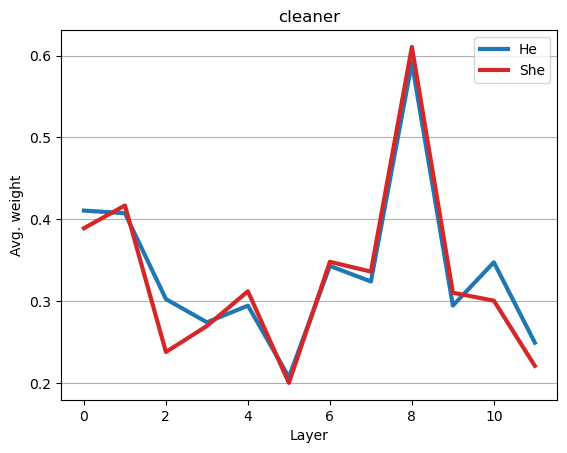

In [13]:
import matplotlib.pyplot as plt

x = [i for i in range(12)]
plt.plot(x, layers_m, linewidth=3, c='tab:blue', label='He')
plt.plot(x, layers_f, linewidth=3, c='tab:red', label='She')
plt.grid(axis='y')
plt.legend()

plt.title(occupation_word)
plt.xlabel('Layer')
plt.ylabel('Avg. weight')
plt.show()

#### 箱ひげ図
最も差がありそうな8,9,10層目(0-11中)の差の合計を各文について求めて，箱ひげ図にする

In [4]:
def attention_differensce(occupation):
    #対象の職業単語
    occupation_word = occupation
    occupation_inputs = tokenizer(occupation_word, return_tensors='pt', add_special_tokens=False)
    occupation_ids = occupation_inputs['input_ids']
    occupations = tokenizer.convert_ids_to_tokens(occupation_ids[0])
    
    #各データセット
    sub_data_m = data_male[occupation_word]
    sub_data_f = data_female[occupation_word]
    
    #結果を格納
    diff_result = []
    
    #各職業100文章
    for i in range(len(sub_data_m)):
        diffs = []
        
        #8,9,10層目について
        for layer in range(8,11):
            #初期化
            pos_m_oc = 0
            pos_f_oc = 0
    
            #男性文
            text_m = sub_data_m[i]
            inputs_m = tokenizer(text_m, return_tensors='pt')
            ids_m = inputs_m['input_ids']
            tokens_m = tokenizer.convert_ids_to_tokens(ids_m[0])
    
            with torch.no_grad():
                outputs_m = model(**inputs_m, output_attentions=True)
                attentions_m = outputs_m.attentions
    
            for j in range(len(tokens_m)): #職業単語の位置を取得
                if tokens_m[j] == occupations[0]:
                    pos_m_oc = j
    
            if pos_m_oc == 0:
                print("Occupation word not included!")
                break
        
            attentions_m = attentions_m[layer][0].detach().numpy() #最終層とバッチの取り出し
            attentions_m = attentions_m.sum(axis=0) #headの合計
            male_weight = attentions_m[pos_m_oc, 1] #欲しい値
    
    
            #女性文
            text_f = sub_data_f[i]
            inputs_f = tokenizer(text_f, return_tensors='pt')
            ids_f = inputs_f['input_ids']
            tokens_f = tokenizer.convert_ids_to_tokens(ids_f[0])
    
            with torch.no_grad():
                outputs_f = model(**inputs_f, output_attentions=True)
                attentions_f = outputs_f.attentions
    
            for j in range(len(tokens_f)): #職業単語の位置を取得
                if tokens_f[j] == occupations[0]:
                    pos_f_oc = j
    
            if pos_f_oc == 0:
                print("Occupation word not included!")
                break
    
            attentions_f = attentions_f[layer][0].detach().numpy() #最終層とバッチの取り出し
            attentions_f = attentions_f.sum(axis=0) #headの合計
            female_weight = attentions_f[pos_f_oc, 1] #欲しい値
    
            diff = male_weight - female_weight #各レイヤーの差
            diffs.append(diff)

        #print(len(diffs))
        attn = sum(diffs) #8-10層の差の合計
        diff_result.append(attn)
        
    return(diff_result)

In [5]:
target_occupations1 = ['carpenter', 'driver', 'sheriff', 'developer', 'farmer', 'guard', 'chief', 
                      'lawyer', 'cook', 'physician', 'CEO'] 

target_occupations2 = ['analyst', 'manager', 'supervisor', 'editor', 'designer', 'accountant', 
                       'auditor', 'writer', 'baker', 'clerk'] 

target_occupations3 = ['counselor', 'attendant', 'teacher', 'sewer', 'librarian', 'assistant', 
                       'cleaner', 'housekeeper', 'nurse', 'receptionist', 'secretary']
#print(len(target_occupations))

output_result = {}

In [ ]:
for occupation in tqdm(target_occupations1):
    result = attention_differensce(occupation)
    output_result[occupation] = result
    print(len(result))

In [8]:
with open('result_8_to_10.json', 'w') as f:
    json.dump(output_result, f, indent=2)

In [6]:
with open('result_8_to_10.json', 'r') as f:
    output_result = json.load(f)

In [ ]:
for occupation in tqdm(target_occupations2):
    result = attention_differensce(occupation)
    output_result[occupation] = result
    print(len(result))

In [12]:
with open('result_8_to_10.json', 'w') as f:
    json.dump(output_result, f, indent=2)

In [ ]:
for occupation in tqdm(target_occupations3):
    result = attention_differensce(occupation)
    output_result[occupation] = result
    print(len(result))

In [15]:
with open('result_8_to_10.json', 'w') as f:
    json.dump(output_result, f, indent=2)

#### 箱ひげ図で可視化

In [10]:
import matplotlib.pyplot as plt

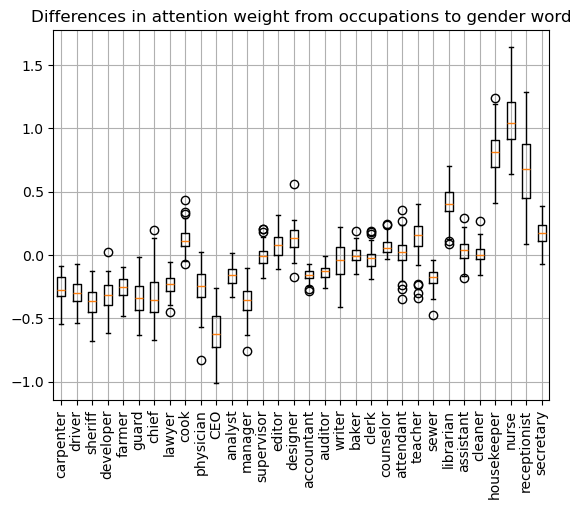

In [18]:
carpenter = output_result['carpenter']
driver = output_result['driver']
sheriff = output_result['sheriff']
developer = output_result['developer']
farmer = output_result['farmer']
guard = output_result['guard']
chief = output_result['chief']
lawyer = output_result['lawyer']
cook = output_result['cook']
physician = output_result['physician']
ceo = output_result['CEO']
analyst = output_result['analyst']
manager = output_result['manager']
supervisor = output_result['supervisor']
editor = output_result['editor']
designer = output_result['designer']
accountant = output_result['accountant']
auditor = output_result['auditor']
writer = output_result['writer']
baker = output_result['baker']
clerk = output_result['clerk']
counselor = output_result['counselor']
attendant = output_result['attendant']
teacher = output_result['teacher']
sewer = output_result['sewer']
librarian = output_result['librarian']
assistant = output_result['assistant']
cleaner = output_result['cleaner']
housekeeper = output_result['housekeeper']
nurse = output_result['nurse']
receptionist = output_result['receptionist']
secretary = output_result['secretary']

labels = ["carpenter", "driver", "sheriff",
         "developer", "farmer", "guard", "chief", "lawyer", "cook", 
          "physician", "CEO", "analyst", "manager", "supervisor", "editor",
          "designer", "accountant", "auditor", "writer", "baker", "clerk", "counselor",
          "attendant", "teacher", "sewer", "librarian", "assistant", "cleaner", "housekeeper",
          "nurse", "receptionist", "secretary"]

plt.boxplot((carpenter, driver, sheriff, 
             developer, farmer, guard, chief, lawyer, cook, physician,
             ceo, analyst, manager, supervisor, editor, designer, accountant,
             auditor, writer, baker, clerk, counselor, attendant, teacher, sewer, librarian,
             assistant, cleaner, housekeeper, nurse, receptionist, secretary), tick_labels=labels)
#plt.boxplot((mechanician, worker, laborer, mover, janitor, salesperson, cashier), tick_labels=labels)
plt.xticks(rotation=90)
plt.grid()
plt.title("Differences in attention weight from occupations to gender word")
plt.show()

#### [MASK]予測の確率の差

In [4]:
target_occupations = ['carpenter', 'driver', 'sheriff', 'developer', 'farmer', 'guard', 'chief', 
                       'lawyer', 'cook', 'physician', 'CEO', 'analyst', 'manager', 'supervisor', 
                       'editor', 'designer', 'accountant', 'auditor', 'writer', 'baker', 'clerk',
                       'counselor', 'attendant', 'teacher', 'sewer', 'librarian', 'assistant', 
                       'cleaner', 'housekeeper', 'nurse', 'receptionist', 'secretary']

print(len(target_occupations))

32


In [7]:
model_version = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_version)
model = BertForMaskedLM.from_pretrained(model_version, output_attentions=True)

/opt/anaconda3/envs/m1-gender/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (

In [8]:
def mask_predict(occupation):
    # 性別単語を[MASK]，　主語を予測
    occupation_word = occupation
    male_sentences = data_male[occupation_word]
    female_sentences = data_female[occupation_word]
    mask_id = tokenizer.mask_token_id
    she_token_id = tokenizer.convert_tokens_to_ids("she")
    he_token_id = tokenizer.convert_tokens_to_ids("he")
    prob_diff = {}
    counter = 0

    for i in tqdm(range(len(male_sentences))):
        pos_m = []
        pos_f = []
        sent_male = male_sentences[i]
        sent_female = female_sentences[i]
    
        #文のトークナイズ男性
        inputs_male = tokenizer(sent_male, return_tensors='pt')
        tokens_male = tokenizer.convert_ids_to_tokens(inputs_male.input_ids[0])
    
        #文のトークナイズ女性
        inputs_female = tokenizer(sent_female, return_tensors='pt')
        tokens_female = tokenizer.convert_ids_to_tokens(inputs_female.input_ids[0])
    
        #性別単語の位置
        for j in range(len(tokens_male)):
            if tokens_male[j] not in tokens_female:
                pos_m.append(j)
    
        for j in range(len(tokens_female)):
            if tokens_female[j] not in tokens_male:
                pos_f.append(j)

        #性別の単語をマスク
        for pos in pos_m:
            inputs_male["input_ids"][0, pos] = mask_id
    
        for pos in pos_f:
            inputs_female["input_ids"][0, pos] = mask_id
    
        #print(len(tokenizer.convert_ids_to_tokens(inputs_male['input_ids'][0])))
        #print(tokenizer.convert_ids_to_tokens(inputs_female['input_ids'][0]), "\n")
    
        with torch.no_grad():
            outputs = model(**inputs_male)
    
        logits = outputs.logits
        mask_logits = logits[0, pos_m[0], :]
        probabilities = F.softmax(mask_logits, dim=-1)
        predicted_token_id = mask_logits.argmax(dim=-1)
        predicted_token = tokenizer.decode([predicted_token_id])
    
        #print('sheが予測される確率 : ', probabilities[she_token_id].item())
        #print('heが予測される確率 : ', probabilities[he_token_id].item(), "\n")
        
        he_she = probabilities[he_token_id].item() - probabilities[she_token_id].item()
        #prob_diff[i] = he_she
        if he_she < 0:
            counter+=1
    
    return counter

In [9]:
num = mask_predict('carpenter')
print(num)

100%|██████████| 100/100 [00:25<00:00,  3.92it/s]

1


In [ ]:
nums = {}
for oc in target_occupations:
    num = mask_predict(oc)
    nums[oc] = num

In [13]:
with open('predicted_nums.json', 'w') as f:
    json.dump(nums, f, indent=2)

#### 並べ替えて箱ひげ図

In [6]:
with open('predicted_nums.json', 'r') as f:
    nums = json.load(f)

In [8]:
nums2 = sorted(nums.items(), key=lambda x:x[1])
print(nums2)

[('sheriff', 0), ('developer', 0), ('farmer', 0), ('guard', 0), ('CEO', 0), ('analyst', 0), ('accountant', 0), ('carpenter', 1), ('manager', 1), ('driver', 2), ('auditor', 3), ('physician', 5), ('sewer', 5), ('chief', 6), ('lawyer', 6), ('supervisor', 40), ('baker', 44), ('writer', 46), ('designer', 49), ('clerk', 54), ('editor', 57), ('cleaner', 83), ('attendant', 87), ('assistant', 88), ('teacher', 90), ('secretary', 96), ('cook', 98), ('counselor', 99), ('librarian', 99), ('housekeeper', 100), ('nurse', 100), ('receptionist', 100)]


In [13]:
t = []
for oc in nums2:
    t.append(oc[0])
print(t)

['sheriff', 'developer', 'farmer', 'guard', 'CEO', 'analyst', 'accountant', 'carpenter', 'manager', 'driver', 'auditor', 'physician', 'sewer', 'chief', 'lawyer', 'supervisor', 'baker', 'writer', 'designer', 'clerk', 'editor', 'cleaner', 'attendant', 'assistant', 'teacher', 'secretary', 'cook', 'counselor', 'librarian', 'housekeeper', 'nurse', 'receptionist']


In [9]:
with open('result_8_to_10.json', 'r') as f:
    output_result = json.load(f)

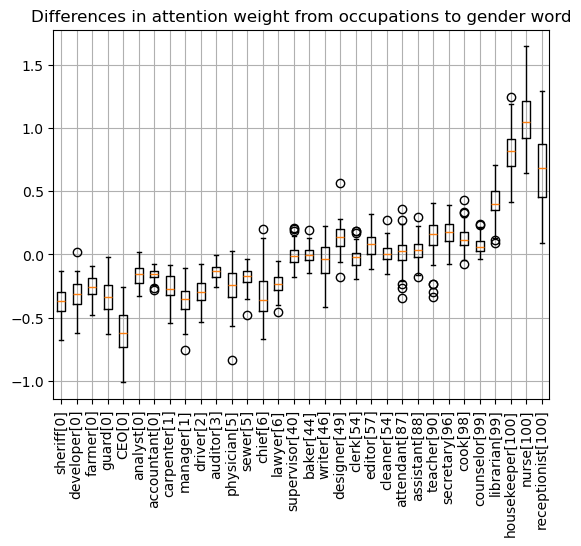

In [14]:
carpenter = output_result['carpenter']
driver = output_result['driver']
sheriff = output_result['sheriff']
developer = output_result['developer']
farmer = output_result['farmer']
guard = output_result['guard']
ceo = output_result['CEO']
chief = output_result['chief']
lawyer = output_result['lawyer']
cook = output_result['cook']
physician = output_result['physician']
analyst = output_result['analyst']
manager = output_result['manager']
supervisor = output_result['supervisor']
editor = output_result['editor']
designer = output_result['designer']
accountant = output_result['accountant']
auditor = output_result['auditor']
writer = output_result['writer']
baker = output_result['baker']
clerk = output_result['clerk']
counselor = output_result['counselor']
attendant = output_result['attendant']
teacher = output_result['teacher']
sewer = output_result['sewer']
librarian = output_result['librarian']
assistant = output_result['assistant']
cleaner = output_result['cleaner']
housekeeper = output_result['housekeeper']
nurse = output_result['nurse']
receptionist = output_result['receptionist']
secretary = output_result['secretary']

labels = ['sheriff[0]', 'developer[0]', 'farmer[0]', 'guard[0]', 'CEO[0]', 'analyst[0]','accountant[0]',
          'carpenter[1]', 'manager[1]', 
          'driver[2]', 'auditor[3]', 'physician[5]', 'sewer[5]', 'chief[6]', 'lawyer[6]', 'supervisor[40]', 
          'baker[44]', 'writer[46]', 
          'designer[49]', 'clerk[54]', 'editor[57]', 'cleaner[54]', 'attendant[87]', 'assistant[88]', 
          'teacher[90]', 'secretary[96]', 'cook[98]', 'counselor[99]', 'librarian[99]', 
          'housekeeper[100]', 'nurse[100]', 'receptionist[100]']

plt.boxplot((sheriff, developer, farmer, guard, ceo, analyst, accountant, carpenter, 
             manager, driver, auditor, physician, sewer, chief, lawyer, supervisor, 
             baker, writer, designer, clerk, editor, cleaner, attendant, 
             assistant, teacher, secretary, cook, counselor, librarian, 
             housekeeper, nurse, receptionist), tick_labels=labels)
#plt.boxplot((mechanician, worker, laborer, mover, janitor, salesperson, cashier), tick_labels=labels)
plt.xticks(rotation=90)
plt.grid()
plt.title("Differences in attention weight from occupations to gender word")
plt.show()